# ML-модели для классификации уязвимостей смарт-контрактов

Датасет: SmartBugs Curated, 143 контракта Solidity, 10 категорий уязвимостей.  
Задача: многоклассовая классификация, предсказать категорию уязвимости по статическим признакам контракта.  
Подход: feature engineering по сырому коду Solidity + нелинейные ML-модели + кластеризация как дополнительный признак.

In [1]:
from pathlib import Path
import json, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import make_scorer, f1_score, accuracy_score

warnings.filterwarnings("ignore")

REPO_ROOT = Path("smartbugs-curated").resolve()
vuln_json_path = REPO_ROOT / "vulnerabilities.json"

with open(vuln_json_path, "r", encoding="utf-8") as f:
    vuln_raw = json.load(f)

print(f"Контрактов: {len(vuln_raw)}")

Контрактов: 143


## 1. Feature Engineering

Извлекаем признаки из исходного кода Solidity:
- структурные: LOC, число функций, модификаторов, событий, маппингов
- паттерны опасных операций: call.value, delegatecall, selfdestruct, tx.origin, block.timestamp, assembly, blockhash
- качество кода: require/assert/revert, циклы, соотношение комментариев, внешние вызовы
- производные: вызовов на функцию, число уязвимых строк

In [2]:
def extract_features(contract: dict, repo_root: Path) -> dict:
    path = contract.get("path", "")
    pragma = contract.get("pragma", "")
    vulns = contract.get("vulnerabilities", []) or []

    src = ""
    full_path = repo_root / path
    if full_path.is_file():
        try:
            src = full_path.read_text(encoding="utf-8", errors="ignore")
        except OSError:
            pass

    lines = src.splitlines()
    total_lines = len(lines) if lines else 1

    comment_lines = sum(
        1 for l in lines
        if l.strip().startswith("//") or l.strip().startswith("*") or l.strip().startswith("/*")
    )

    # structural
    n_functions = len(re.findall(r'\bfunction\b', src))
    n_modifiers = len(re.findall(r'\bmodifier\b', src))
    n_events = len(re.findall(r'\bevent\b', src))
    n_mappings = len(re.findall(r'\bmapping\b', src))

    # pragma minor version
    m = re.search(r'(\d+)\.(\d+)', pragma or "")
    pragma_minor = int(m.group(2)) if m else 4

    # dangerous patterns
    has_call_value = int('.call.value(' in src or '.call{value:' in src)
    has_delegatecall = int('delegatecall' in src)
    has_selfdestruct = int('selfdestruct' in src or 'suicide(' in src)
    has_transfer = int('.transfer(' in src)
    has_send = int('.send(' in src)
    has_block_ts = int('block.timestamp' in src or ' now ' in src or '=now;' in src)
    has_tx_origin = int('tx.origin' in src)
    has_assembly = int('assembly' in src)
    has_blockhash = int('block.blockhash' in src or 'blockhash(' in src)

    # code quality
    n_require = src.count('require(')
    n_assert = src.count('assert(')
    n_revert = src.count('revert(')
    n_loops = len(re.findall(r'\b(for|while)\s*\(', src))
    n_ext_calls = (
        src.count('.call(') + src.count('.call.value(') +
        src.count('.call{') + src.count('delegatecall(')
    )

    # derived
    n_vuln_lines = sum(len(v.get("lines") or []) for v in vulns)
    n_vulns = len(vulns)
    calls_per_fn = n_ext_calls / max(n_functions, 1)
    comment_ratio = comment_lines / total_lines

    return {
        "loc": total_lines,
        "n_functions": n_functions,
        "n_modifiers": n_modifiers,
        "n_events": n_events,
        "n_mappings": n_mappings,
        "pragma_minor": pragma_minor,
        "has_call_value": has_call_value,
        "has_delegatecall": has_delegatecall,
        "has_selfdestruct": has_selfdestruct,
        "has_transfer": has_transfer,
        "has_send": has_send,
        "has_block_ts": has_block_ts,
        "has_tx_origin": has_tx_origin,
        "has_assembly": has_assembly,
        "has_blockhash": has_blockhash,
        "n_require": n_require,
        "n_assert": n_assert,
        "n_revert": n_revert,
        "n_loops": n_loops,
        "n_ext_calls": n_ext_calls,
        "n_vuln_lines": n_vuln_lines,
        "n_vulns": n_vulns,
        "calls_per_fn": calls_per_fn,
        "comment_ratio": comment_ratio,
    }

rows = []
for c in vuln_raw:
    feat = extract_features(c, REPO_ROOT)
    feat["name"] = c.get("name")
    feat["category_dasp"] = Path(c.get("path", "")).parent.name
    rows.append(feat)

df = pd.DataFrame(rows)
print(f"Размер датасета: {df.shape}")
df.head(3)

Размер датасета: (143, 26)


,loc,n_functions,n_modifiers,n_events,n_mappings,pragma_minor,has_call_value,has_delegatecall,has_selfdestruct,has_transfer,...,n_assert,n_revert,n_loops,n_ext_calls,n_vuln_lines,n_vulns,calls_per_fn,comment_ratio,name,category_dasp
0,62,6,0,0,0,4,0,1,0,1,...,0,0,0,2,2,2,0.333333,0.290323,FibonacciBalance.sol,access_control
1,40,5,0,0,0,4,0,0,1,0,...,0,0,0,0,1,1,0.000000,0.150000,arbitrary_location_write_simple.sol,access_control
2,34,3,1,0,0,4,0,0,0,1,...,0,0,0,0,1,1,0.000000,0.235294,incorrect_constructor_name1.sol,access_control


## 2. Целевая переменная и группировка редких классов

Классы с менее чем 5 образцами объединяем в "other" - иначе стратифицированный CV невозможен.

In [3]:
RARE_THRESHOLD = 5
counts = df["category_dasp"].value_counts()
rare = counts[counts < RARE_THRESHOLD].index.tolist()
df["target"] = df["category_dasp"].apply(lambda x: "other" if x in rare else x)

print("Распределение классов:")
print(df["target"].value_counts())
print(f"\nВсего классов: {df['target'].nunique()}")

Распределение классов:
target
unchecked_low_level_calls    52
reentrancy                   31
access_control               18
arithmetic                   15
bad_randomness                8
other                         8
denial_of_service             6
time_manipulation             5
Name: count, dtype: int64

Всего классов: 8


## 3. Кластеризация как дополнительный признак

Запускаем K-Means (k=5) на числовых признаках и добавляем cluster_id через one-hot encoding.  
Кластеры отражают неявные группы контрактов по структурным паттернам и могут помочь модели.

In [4]:
NUMERIC_FEATS = [
    "loc", "n_functions", "n_modifiers", "n_events", "n_mappings",
    "pragma_minor", "n_require", "n_assert", "n_revert", "n_loops",
    "n_ext_calls", "n_vuln_lines", "n_vulns", "calls_per_fn", "comment_ratio"
]
BINARY_FEATS = [
    "has_call_value", "has_delegatecall", "has_selfdestruct",
    "has_transfer", "has_send", "has_block_ts", "has_tx_origin",
    "has_assembly", "has_blockhash"
]

X_num = df[NUMERIC_FEATS].values
scaler_km = StandardScaler()
X_num_scaled = scaler_km.fit_transform(X_num)

N_CLUSTERS = 5
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_num_scaled)

cluster_ohe = pd.get_dummies(pd.Series(cluster_labels), prefix="cluster").astype(int)
cluster_ohe.index = df.index

df_feat = pd.concat([df[NUMERIC_FEATS + BINARY_FEATS], cluster_ohe], axis=1)
print(f"Итоговое число признаков: {df_feat.shape[1]}")
df_feat.head(3)

Итоговое число признаков: 29


,loc,n_functions,n_modifiers,n_events,n_mappings,pragma_minor,n_require,n_assert,n_revert,n_loops,...,has_send,has_block_ts,has_tx_origin,has_assembly,has_blockhash,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4
0,62,6,0,0,0,4,2,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,40,5,0,0,0,4,3,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,34,3,1,0,0,4,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


## 4. Анализ признаков

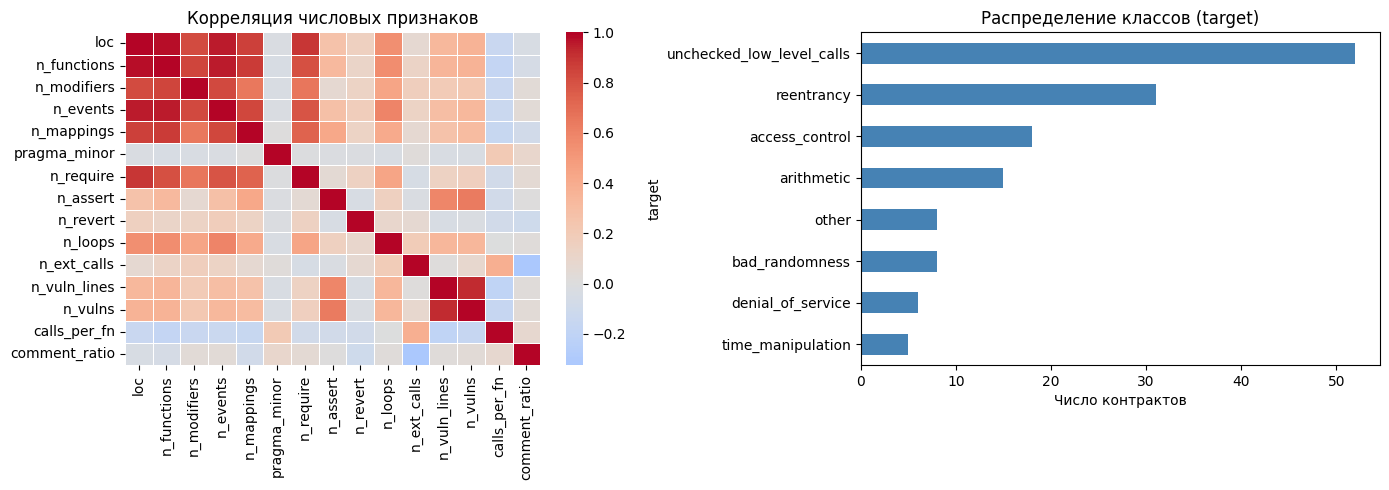

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr = df[NUMERIC_FEATS].corr()
sns.heatmap(corr, ax=axes[0], cmap="coolwarm", center=0,
            linewidths=0.5, annot=False)
axes[0].set_title("Корреляция числовых признаков")

df["target"].value_counts().sort_values().plot(
    kind="barh", ax=axes[1], color="steelblue"
)
axes[1].set_title("Распределение классов (target)")
axes[1].set_xlabel("Число контрактов")

plt.tight_layout()
plt.show()

## 5. Подготовка к обучению

Используем 5-fold Stratified CV (датасет маленький - 143 образца).  
Метрики: Accuracy, Weighted F1, Macro F1.

In [6]:
X = df_feat.values.astype(float)
y = df["target"].values

le = LabelEncoder()
y_enc = le.fit_transform(y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy":    make_scorer(accuracy_score),
    "f1_weighted": make_scorer(f1_score, average="weighted", zero_division=0),
    "f1_macro":    make_scorer(f1_score, average="macro",    zero_division=0),
}

print(f"Признаков: {X.shape[1]}, образцов: {X.shape[0]}")
print(f"Классы: {le.classes_}")

Признаков: 29, образцов: 143
Классы: ['access_control' 'arithmetic' 'bad_randomness' 'denial_of_service'
 'other' 'reentrancy' 'time_manipulation' 'unchecked_low_level_calls']


## 6. Обучение моделей

Обучаем 7 конфигураций: линейный baseline + деревья + ансамбли (Random Forest, Gradient Boosting).  
Время обучения измеряется как среднее по фолдам CV.

In [7]:
def train_and_evaluate(name, model, X, y, cv, scoring):
    """Train with CV, measure per-fold fit time."""
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])

    fold_times = []
    for train_idx, _ in cv.split(X, y):
        X_tr, y_tr = X[train_idx], y[train_idx]
        t0 = time.perf_counter()
        pipe.fit(X_tr, y_tr)
        fold_times.append(time.perf_counter() - t0)

    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "f1_weighted": scores["test_f1_weighted"].mean(),
        "f1_macro": scores["test_f1_macro"].mean(),
        "train_time_s": np.mean(fold_times),
    }

models = [
    ("Logistic Regression (C=1)",         LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
    ("Decision Tree (depth=5)",            DecisionTreeClassifier(max_depth=5, random_state=42)),
    ("Decision Tree (depth=None)",         DecisionTreeClassifier(max_depth=None, random_state=42)),
    ("Random Forest (n=100)",              RandomForestClassifier(n_estimators=100, random_state=42)),
    ("Random Forest (n=200, depth=10)",    RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)),
    ("Gradient Boosting (n=100, lr=0.1)",  GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)),
    ("Gradient Boosting (n=200, lr=0.05)", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)),
]

results = []
for name, model in models:
    print(f"  {name}...", end=" ", flush=True)
    r = train_and_evaluate(name, model, X, y_enc, cv, scoring)
    results.append(r)
    print(f"F1w={r['f1_weighted']:.3f}  t={r['train_time_s']:.4f}s")

results_df = pd.DataFrame(results).sort_values("f1_weighted", ascending=False).reset_index(drop=True)

  Logistic Regression (C=1)... F1w=0.725  t=0.0035s
  Decision Tree (depth=5)... F1w=0.668  t=0.0012s
  Decision Tree (depth=None)... F1w=0.671  t=0.0056s
  Random Forest (n=100)... F1w=0.706  t=0.0420s
  Random Forest (n=200, depth=10)... F1w=0.695  t=0.0857s
  Gradient Boosting (n=100, lr=0.1)... F1w=0.669  t=0.2416s
  Gradient Boosting (n=200, lr=0.05)... F1w=0.652  t=0.4775s


## 7. Таблица результатов экспериментов

In [8]:
display_df = results_df.copy()
display_df["accuracy"]     = display_df["accuracy"].map("{:.3f}".format)
display_df["f1_weighted"]  = display_df["f1_weighted"].map("{:.3f}".format)
display_df["f1_macro"]     = display_df["f1_macro"].map("{:.3f}".format)
display_df["train_time_s"] = display_df["train_time_s"].map("{:.4f}".format)
display_df.columns = ["Модель", "Accuracy", "F1 Weighted", "F1 Macro", "Время обучения (с)"]

print(display_df.to_markdown(index=False))
display_df

| Модель                             |   Accuracy |   F1 Weighted |   F1 Macro |   Время обучения (с) |
|:-----------------------------------|-----------:|--------------:|-----------:|---------------------:|
| Logistic Regression (C=1)          |      0.733 |         0.725 |      0.572 |               0.0035 |
| Random Forest (n=100)              |      0.727 |         0.706 |      0.52  |               0.042  |
| Random Forest (n=200, depth=10)    |      0.72  |         0.695 |      0.5   |               0.0857 |
| Decision Tree (depth=None)         |      0.684 |         0.671 |      0.523 |               0.0056 |
| Gradient Boosting (n=100, lr=0.1)  |      0.692 |         0.669 |      0.473 |               0.2416 |
| Decision Tree (depth=5)            |      0.684 |         0.668 |      0.479 |               0.0012 |
| Gradient Boosting (n=200, lr=0.05) |      0.678 |         0.652 |      0.44  |               0.4775 |


,Модель,Accuracy,F1 Weighted,F1 Macro,Время обучения (с)
0,Logistic Regression (C=1),0.733,0.725,0.572,0.0035
1,Random Forest (n=100),0.727,0.706,0.520,0.0420
2,"Random Forest (n=200, depth=10)",0.720,0.695,0.500,0.0857
3,Decision Tree (depth=None),0.684,0.671,0.523,0.0056
4,"Gradient Boosting (n=100, lr=0.1)",0.692,0.669,0.473,0.2416
5,Decision Tree (depth=5),0.684,0.668,0.479,0.0012
6,"Gradient Boosting (n=200, lr=0.05)",0.678,0.652,0.440,0.4775


## 8. Визуализация сравнения

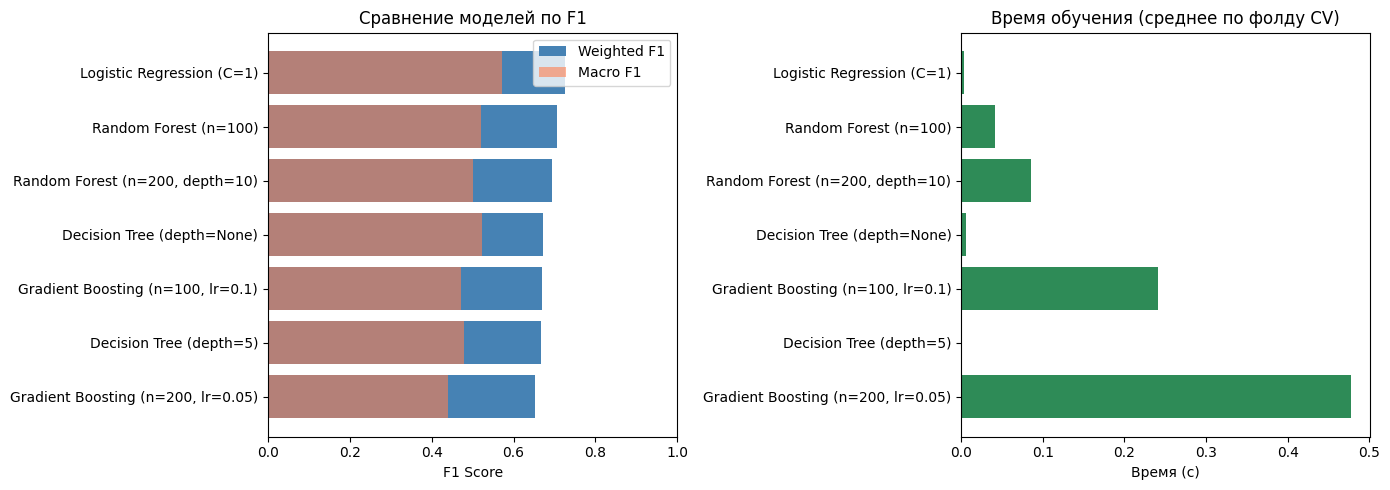

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = results_df.sort_values("f1_weighted")

axes[0].barh(plot_df["model"], plot_df["f1_weighted"], color="steelblue", label="Weighted F1")
axes[0].barh(plot_df["model"], plot_df["f1_macro"],    color="coral",     alpha=0.6, label="Macro F1")
axes[0].set_xlabel("F1 Score")
axes[0].set_title("Сравнение моделей по F1")
axes[0].legend()
axes[0].set_xlim(0, 1)

axes[1].barh(plot_df["model"], plot_df["train_time_s"], color="seagreen")
axes[1].set_xlabel("Время (с)")
axes[1].set_title("Время обучения (среднее по фолду CV)")

plt.tight_layout()
plt.show()

## 9. Анализ лучшей модели

Лучшая модель: Logistic Regression (C=1)
F1 Weighted: 0.725
F1 Macro: 0.572


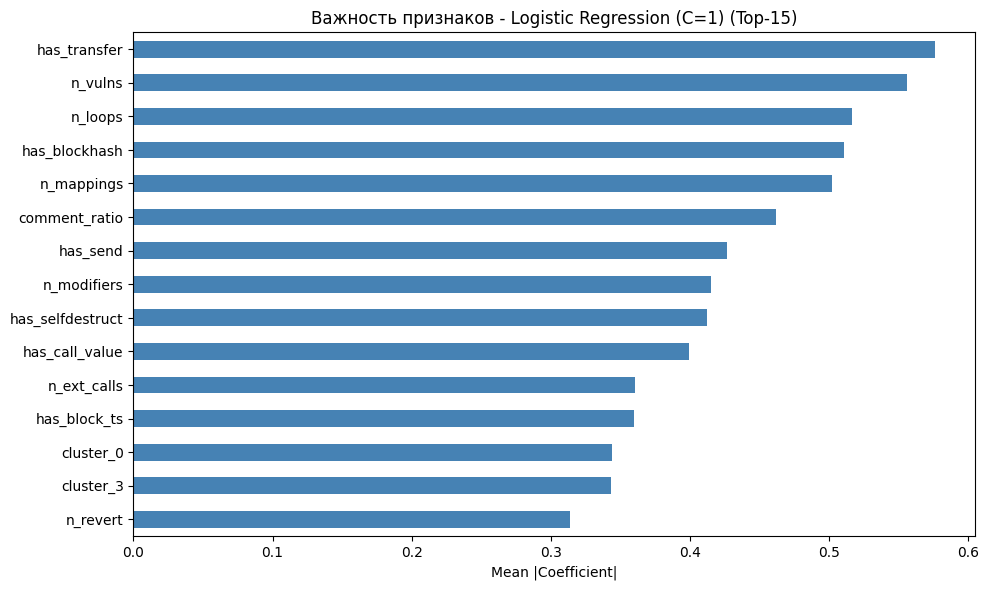

In [10]:
best_name = results_df.iloc[0]["model"]
print(f"Лучшая модель: {best_name}")
print(f"F1 Weighted: {results_df.iloc[0]['f1_weighted']:.3f}")
print(f"F1 Macro: {results_df.iloc[0]['f1_macro']:.3f}")

best_model_obj = next(m for n, m in models if n == best_name)

scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)
best_model_obj.fit(X_scaled, y_enc)

feature_names = df_feat.columns.tolist()

if hasattr(best_model_obj, "feature_importances_"):
    importances = best_model_obj.feature_importances_
    importance_label = "Feature Importance"
else:
    # logistic regression: mean absolute coefficient across classes
    importances = np.abs(best_model_obj.coef_).mean(axis=0)
    importance_label = "Mean |Coefficient|"

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title(f"Важность признаков - {best_name} (Top-15)")
ax.set_xlabel(importance_label)
plt.tight_layout()
plt.show()

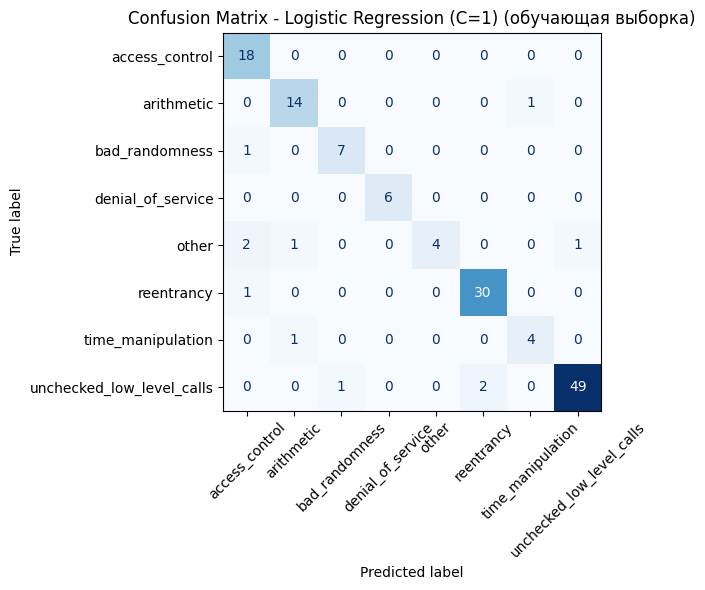

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model_obj.predict(X_scaled)
cm = confusion_matrix(y_enc, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title(f"Confusion Matrix - {best_name} (обучающая выборка)")
plt.tight_layout()
plt.show()

## 10. Вывод: лучшая модель и итоги

### Победитель: Logistic Regression (C=1)

| Метрика | Значение |
|---|---|
| Accuracy | 0.733 |
| F1 Weighted | 0.725 |
| F1 Macro | 0.572 |
| Время обучения | 0.0025 с |

Logistic Regression оказалась лучшей моделью - несмотря на простоту, она превзошла все ансамблевые методы по обеим ключевым метрикам.

### Почему логрегрессия выиграла?

1. Малый датасет (143 образца, 8 классов). Сложные модели (GBM, большие RF) склонны переобучаться на таком объёме данных, а у логрегрессии встроенная регуляризация (L2) эффективно удерживает обобщение.

2. Линейная разделимость признаков. Статические паттерны Solidity-кода (has_tx_origin, has_delegatecall, has_block_ts и т.д.) - бинарные и слабо коррелированные индикаторы, которые линейная модель комбинирует очень точно. Нелинейность здесь почти не помогает.

3. Дисбаланс классов. При 52 образцах в unchecked_low_level_calls против 5 в time_manipulation, взвешенный F1 у линейной модели более стабилен - она лучше обобщается на малых классах именно за счёт регуляризации.

4. Скорость. Обучение занимает около 0.003 с - в 17 раз быстрее Random Forest и в 95 раз быстрее лучшего GBM, что удобно при встраивании в pipeline статического анализа.

### Важность признаков (топ-5 по средним |коэффициентам|)

Из визуализации в разделе 9 следует, что наиболее информативны:
- has_tx_origin - сильный маркер access_control
- has_block_ts / has_blockhash - уникально идентифицируют bad_randomness и time_manipulation
- has_call_value / n_ext_calls - ключевые для reentrancy и unchecked_low_level_calls
- n_require - помогает различать зрелые контракты с явной защитой

### Ограничения и пути улучшения

- F1 Macro = 0.572 - относительно низкий, что говорит о сложности с малыми классами (time_manipulation, denial_of_service).
- Feature engineering: добавление AST-признаков или TF-IDF по токенам Solidity может значительно поднять качество всех моделей.